# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JasperOwen/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

Search traffic decay can cause a major loss of discoverability and revenue for website owners. Therefore, as part of the Flyrank Refresh Opportunity Scoring Lane, I investigated whether observable page performance data can be used to identify signs of future content decay and prioritize web pages for review.

Using 13,531 page records from March 2026, I created a leak-free 12-feature dataset, and evaluated multiple models on it using a 5-fold client-holdout split. My Random Forest model achieved a mean Precision@50 score of 0.876, which was the highest mean Precision@50 out of all my models.

Finally, I converted these predictions into a priority score between 0 and 100, and created a series of recommended actions to accompany these priority scores. This resulted in 18.6% of the pages in the dataset (2,520/13,531) being given the review_for_refresh suggested action, which human editors can use as a guide when deciding if a page needs refreshing or not.

## 1. Question

*The research question and the decision it supports.*

### Research Question
Which pages should be reviewed first for expansion, reduction or refreshing based on changes in visibility and engagement compared to their previous rates?

### Decision
My work improves the decision of which pages to review first for potential updates. This is because instead of manually reviewing each page they find, or using static heuristics, an editing team can use my work to see which pages my model recommends that they should review for refresh. They can then use that data to help them decide which pages to review.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset
* **Release:** March 2026 production warehouse release from `FlyRank/internship-warehouse` on Hugging Face.
* **Table:** `fact_content_daily_performance` filtered by `month=2026-03`.
* **Grain:** In the table, one row is the performance of one page that belongs to one client in one day. In the dataset I use on my model, the data is aggregated so each row represents the performance of one page that belongs to one client, summarized across March 2026.

### Time Windows & Boundaries
* **Week 1:** March 1–7, 2026.
* **Week 2:** March 8–15, 2026.
* **Decision Moment:** March 15, 2026.
* **Late March (Target window):** March 16–31, 2026.

### Data use
All client names, URLs, domains, and raw search queries are replaced with hash identifiers (`client_hash_id`, `content_hash_id`) in accordance with Flyrank's data use policy.

In [7]:
import os
import sys
import duckdb
import numpy as np
import pandas as pd
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

# 1. Hugging Face Authentication & DuckDB Setup
hf_token = userdata.get("HF_TOKEN") if "google.colab" in sys.modules else os.environ.get("HF_TOKEN")
os.environ["HF_TOKEN"] = hf_token
login(token=hf_token)

con = duckdb.connect()
con.sql("SET enable_http_metadata_cache=true;")

file_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=hf_token
)

page_performance_query = f"""
SELECT
    client_hash_id,
    content_hash_id,

    -- Week 1 (March 1-7) - Last Week
    SUM(CASE WHEN report_date <= '2026-03-07' THEN gsc_clicks ELSE 0 END) AS week1_clicks,
    SUM(CASE WHEN report_date <= '2026-03-07' THEN gsc_impressions ELSE 0 END) AS week1_impressions,
    AVG(CASE WHEN report_date <= '2026-03-07' AND gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END) AS week1_avg_position,

    -- Week 2 (March 8-15) - This Week
    SUM(CASE WHEN report_date > '2026-03-07' AND report_date <= '2026-03-15' THEN gsc_clicks ELSE 0 END) AS week2_clicks,
    SUM(CASE WHEN report_date > '2026-03-07' AND report_date <= '2026-03-15' THEN gsc_impressions ELSE 0 END) AS week2_impressions,
    AVG(CASE WHEN report_date > '2026-03-07' AND report_date <= '2026-03-15' AND gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END) AS week2_avg_position,

    -- Late March (March 16-31) - The Future Target Outcome
    SUM(CASE WHEN report_date > '2026-03-15' THEN gsc_clicks ELSE 0 END) AS late_clicks,
    SUM(CASE WHEN report_date > '2026-03-15' THEN gsc_impressions ELSE 0 END) AS late_impressions,
    AVG(CASE WHEN report_date > '2026-03-15' AND gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END) AS late_avg_position

FROM read_parquet('{file_path}')
WHERE gsc_data_available IS TRUE
  AND ga4_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
ORDER BY client_hash_id, content_hash_id
"""

df = con.sql(page_performance_query).df()
print(f"Loaded {len(df):,} rows from DuckDB.")
df.head(10)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded 63,856 rows from DuckDB.


,client_hash_id,content_hash_id,week1_clicks,week1_impressions,week1_avg_position,week2_clicks,week2_impressions,week2_avg_position,late_clicks,late_impressions,late_avg_position
0,client_08d2847f24cf89c1,content_0071174ee1f89d8a,0.0,0.0,NaN,0.0,0.0,NaN,2.0,22.0,9.081197
1,client_08d2847f24cf89c1,content_07f1fdb8d2a0cf9d,3.0,143.0,9.724694,2.0,22.0,13.929825,2.0,21.0,17.807692
2,client_08d2847f24cf89c1,content_0f0c4d121b9d4aa5,0.0,0.0,NaN,0.0,1.0,4.000000,1.0,7.0,8.208333
3,client_08d2847f24cf89c1,content_12444e383a53d45f,0.0,0.0,NaN,0.0,0.0,NaN,0.0,3.0,19.000000
4,client_08d2847f24cf89c1,content_145bbdb1286836a0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,2.0,10.000000
5,client_08d2847f24cf89c1,content_22e732a59c0a66b5,0.0,0.0,NaN,0.0,0.0,NaN,0.0,9.0,9.312500
6,client_08d2847f24cf89c1,content_253c8424ca1515ff,0.0,0.0,NaN,0.0,1.0,9.000000,0.0,0.0,NaN
7,client_08d2847f24cf89c1,content_253c85b3231603fe,0.0,0.0,NaN,0.0,0.0,NaN,0.0,1.0,6.000000
8,client_08d2847f24cf89c1,content_282a4afdf27795ee,0.0,2.0,19.500000,0.0,2.0,19.500000,0.0,5.0,31.083333
9,client_08d2847f24cf89c1,content_310b314b1b4eeb24,0.0,0.0,NaN,2.0,195.0,7.707682,1.0,167.0,7.149008


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Position Tiers & Target Label Definition
* **Position Tiers:** Search rankings are mapped to five tiers: Tier 1 ($\le 3$), Tier 2 ($4\text{-}10$), Tier 3 ($11\text{-}20$), Tier 4 ($21\text{-}50$), and Tier 5 ($> 50$).
* **Target Label (`future_decline`):** A binary indicator where $1$ means the page's position tier in Late March is worse than its position tier in Week 1. Pages with no tier change or improved tier change are labelled $0$.
* **Dataset Filter:** To evaluate performance change, the dataset filters for pages with valid ranking tiers across all three windows (Week 1, Week 2, and Late March), producing **13,531 pages** with a **17.23% base rate of future decline**.

### Baseline Score
I created a manual baseline score to compare my models against:
`baseline_score = historical_tier_change * visibility_score`

The two variables used in the baseline score are:
* `historical_tier_change`: Position tier drop between Week 1 and Week 2 (`w2_tier - w1_tier`).
* `visibility_score`: A ranking of the number of impressions a page received in week 2. Low ($\le 8) = 1$, Medium ($9\text-459) = 2$, High ($> 459) = 4$. The maximum possible baseline score is 12.0.

The action code used in the baseline rule is review_for_refresh


### My features
All features are calculated strictly from data up to March 15, 2026:
1. `week1_impressions`: The number of search impressions a page received in Week 1.
2. `week2_impressions`: The number of search impressions a page received in Week 2.
3. `week1_avg_position`: The average search ranking position of a page in Week 1.
4. `week2_avg_position`: The average search ranking position of a page in Week 2.
5. `w1_tier`: The average ranking tier of a page in Week 1.
6. `w2_tier`: The average ranking tier of a page in Week 2.
7. `historical_tier_change`: The tier drop of a page from Week 1 to Week 2.
8. `click_change_w1_w2`: The difference between the number of clicks a page got in week 2 and week 1.
9. `impression_change_w1_w2`: The difference between the number of impressions a page got in week 2 and week 1.
10. `log_w2_impressions`: $\log(1 + \text{week2_impressions})$ to account for differences in high visibility pages and low visibility pages.
11. `log_w2_clicks`: $\log(1 + \text{week2_clicks})$ to account for differences between pages that got a lot of clicks and pages that did not get many clicks.
12. `w2_ctr`: Click-through rate in Week 2 ($(\text{clicks} / \text{impressions}) \times 100$).

### Validation and Leakage Control
* **Validation Strategy:** Each model is evaluated using a **5-Fold `GroupKFold` split on `client_hash_id`**. This ensures all pages are separated by client into training and testing data, allowing my models to generalize by analysing data from clients they have not seen before.

* **Leakage Checks:** None of my features come from after my decision point (15th March 2026), meaning no Late March data is used as a feature. The correlations of each of my features are measured against `future_decline` to ensure no feature has an unusually strong correlation with `future_decline`, which would imply data leakage.



In [8]:
import numpy as np
import pandas as pd

def position_tier(pos):
    if pd.isna(pos) or pos == 0:
        return np.nan
    if pos <= 3:
        return 1
    elif pos <= 10:
        return 2
    elif pos <= 20:
        return 3
    elif pos <= 50:
        return 4
    else:
        return 5

df["w1_tier"] = df["week1_avg_position"].apply(position_tier)
df["w2_tier"] = df["week2_avg_position"].apply(position_tier)
df["late_tier"] = df["late_avg_position"].apply(position_tier)


df["historical_tier_change"] = df["w2_tier"] - df["w1_tier"]


def visibility_bucket(impressions):
    if pd.isna(impressions):
        return np.nan
    elif impressions <= 8:
        return "low"
    elif impressions <= 459:
        return "medium"
    else:
        return "high"

df["visibility_bucket"] = df["week2_impressions"].apply(visibility_bucket)
df["visibility_score"] = df["visibility_bucket"].map({"low": 1, "medium": 2, "high": 4})

def calculate_baseline_score(row):
    if pd.notna(row["historical_tier_change"]) and row["historical_tier_change"] > 0:
        return row["historical_tier_change"] * row["visibility_score"]
    else:
        return 0.0

df["baseline_score"] = df.apply(calculate_baseline_score, axis=1)


model_df = df[df["w1_tier"].notna() & df["w2_tier"].notna() & df["late_tier"].notna()].copy().reset_index(drop=True)
model_df["future_decline"] = (model_df["late_tier"] > model_df["w1_tier"]).astype(int)
model_df["click_change_w1_w2"] = model_df["week2_clicks"] - model_df["week1_clicks"]
model_df["impression_change_w1_w2"] = model_df["week2_impressions"] - model_df["week1_impressions"]
model_df["log_w2_impressions"] = np.log1p(model_df["week2_impressions"])
model_df["log_w2_clicks"] = np.log1p(model_df["week2_clicks"])
model_df["w2_ctr"] = np.where(
    model_df["week2_impressions"] > 0,
    (model_df["week2_clicks"] / model_df["week2_impressions"]) * 100,
    0.0
)

feature_columns = [
    "week1_impressions", "week2_impressions", "week1_avg_position", "week2_avg_position",
    "w1_tier", "w2_tier", "historical_tier_change",
    "click_change_w1_w2", "impression_change_w1_w2",
    "log_w2_impressions", "log_w2_clicks", "w2_ctr"
]

X = model_df[feature_columns].fillna(0)
y = model_df["future_decline"].values
clients = model_df["client_hash_id"].values
contents = model_df["content_hash_id"].values
baseline_scores = model_df["baseline_score"].values

print(f"Filtered Dataset: {len(model_df):,} rows")
print(f"Base Rate of Future Decline: {y.mean():.4f} ({y.sum():,} declining pages)")
print(f"Feature Matrix X Shape: {X.shape}")


corr_with_target = model_df[feature_columns].apply(lambda col: col.corr(model_df["future_decline"]))
print("\nCorrelations of features with future_decline target:")
print(corr_with_target.round(4).to_string())

# Check no feature exceeds 0.9 or -0.9 correlation
assert not (corr_with_target.abs() > 0.9).any(), "High correlations, check for leakage"
print("\nLow correlations, leakage is unlikely")

Filtered Dataset: 13,531 rows
Base Rate of Future Decline: 0.1723 (2,332 declining pages)
Feature Matrix X Shape: (13531, 12)

Correlations of features with future_decline target:
week1_impressions         -0.1004
week2_impressions         -0.1064
week1_avg_position        -0.2981
week2_avg_position        -0.1400
w1_tier                   -0.4008
w2_tier                   -0.1427
historical_tier_change     0.4044
click_change_w1_w2        -0.0218
impression_change_w1_w2   -0.0671
log_w2_impressions        -0.2047
log_w2_clicks             -0.0833
w2_ctr                     0.0669

Low correlations, leakage is unlikely


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model Performance
Each model was evaluated across the same 5-fold `GroupKFold` client splits to measure how accurately each model flagged pages that actually showed signs of decline after 15th March 2026:

| Model | Mean Base Rate | P@20 Mean | P@50 Mean (Primary) | P@100 Mean |
| :--- | :---: | :---: | :---: | :---: |
| **Baseline score** | 0.2041 | 0.8800 | 0.8160 | 0.7500 |
| **Logistic Regression** | 0.2041 | 0.8400 | 0.8200 | 0.8260 |
| **Decision Tree (d=4)** | 0.2041 | 0.8200 | 0.8440 | 0.8220 |
| **Random Forest (n=100, d=8)** | 0.2041 | **0.9100** | **0.8760** | **0.8660** |

### Interpretation of Results
* **Best Model:** The Random Forest model achieved the highest mean Precision@50 score of **0.8760**, delivering an improvement over the baseline rule (**0.8160**)

* **Queue Depth Stability:** While the baseline rule has high precision values including 0.816 at Precision@50, the Random Forest consistently maintains highest precision values out of all my models, making it the most reliable model.

* **Top Feature Drivers:** The top 3 features in the Random Forest were:
  1. `historical_tier_change` (Feature importance 26.47%)
  2. `week1_avg_position` (Feature importance 25.28%)
  3. `w1_tier` (Feature importance 18.49%)

In [9]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Precision@K calculation tie-breaking by content_hash_id
def precision_at_k(y_true, scores, content_ids, k):
    eval_df = pd.DataFrame({
        'y': np.asarray(y_true, dtype=int),
        'score': np.asarray(scores, dtype=float),
        'content_hash_id': np.asarray(content_ids, dtype=str)
    })
    sorted_df = eval_df.sort_values(
        by=['score', 'content_hash_id'],
        ascending=[False, True]
    )
    return float(sorted_df.head(k)['y'].mean())

# 5-Fold GroupKFold Cross-Validation on client_hash_id
gkf = GroupKFold(n_splits=5)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=clients), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    contents_test = contents[test_idx]
    base_scores_test = baseline_scores[test_idx]
    base_rate_fold = y_test.mean()

    # Baseline Rule
    fold_results.append({
        'fold': fold, 'model': 'Baseline score', 'mean_base_rate': base_rate_fold,
        'p20': precision_at_k(y_test, base_scores_test, contents_test, 20),
        'p50': precision_at_k(y_test, base_scores_test, contents_test, 50),
        'p100': precision_at_k(y_test, base_scores_test, contents_test, 100)
    })

    # Logistic Regression
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_train_s, y_train)
    p_lr = lr.predict_proba(X_test_s)[:, 1]

    fold_results.append({
        'fold': fold, 'model': 'Logistic Regression', 'mean_base_rate': base_rate_fold,
        'p20': precision_at_k(y_test, p_lr, contents_test, 20),
        'p50': precision_at_k(y_test, p_lr, contents_test, 50),
        'p100': precision_at_k(y_test, p_lr, contents_test, 100)
    })

    # Decision Tree (d=4)
    dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)
    p_dt = dt.predict_proba(X_test)[:, 1]

    fold_results.append({
        'fold': fold, 'model': 'Decision Tree (d=4)', 'mean_base_rate': base_rate_fold,
        'p20': precision_at_k(y_test, p_dt, contents_test, 20),
        'p50': precision_at_k(y_test, p_dt, contents_test, 50),
        'p100': precision_at_k(y_test, p_dt, contents_test, 100)
    })

    # Random Forest (n=100, d=8)
    rf = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    p_rf = rf.predict_proba(X_test)[:, 1]

    fold_results.append({
        'fold': fold, 'model': 'Random Forest (n=100, d=8)', 'mean_base_rate': base_rate_fold,
        'p20': precision_at_k(y_test, p_rf, contents_test, 20),
        'p50': precision_at_k(y_test, p_rf, contents_test, 50),
        'p100': precision_at_k(y_test, p_rf, contents_test, 100)
    })

# Summary Table
fold_df = pd.DataFrame(fold_results)
summary = fold_df.groupby('model').agg({
    'mean_base_rate': 'mean',
    'p20': 'mean',
    'p50': 'mean',
    'p100': 'mean'
}).reset_index()

model_order = ["Baseline score", "Logistic Regression", "Decision Tree (d=4)", "Random Forest (n=100, d=8)"]
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)

print("5-Fold GroupKFold Cross-Validation Summary:")
display(summary.round(4))

final_rf = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
final_rf.fit(X, y)
feat_imp = pd.Series(final_rf.feature_importances_, index=feature_columns).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:")
print(feat_imp.round(4).to_string())

5-Fold GroupKFold Cross-Validation Summary:


,model,mean_base_rate,p20,p50,p100
0,Baseline score,0.2041,0.88,0.816,0.750
1,Logistic Regression,0.2041,0.84,0.820,0.826
2,Decision Tree (d=4),0.2041,0.82,0.844,0.822
3,"Random Forest (n=100, d=8)",0.2041,0.91,0.876,0.866



Random Forest Feature Importances:
historical_tier_change     0.2647
week1_avg_position         0.2528
w1_tier                    0.1849
week2_avg_position         0.0929
week1_impressions          0.0436
week2_impressions          0.0412
w2_tier                    0.0349
log_w2_impressions         0.0322
impression_change_w1_w2    0.0210
w2_ctr                     0.0133
log_w2_clicks              0.0106
click_change_w1_w2         0.0080


## 5. Limitations

*What this work cannot claim.*

* **Decline not confirmed:** This model detects statistical patterns in page performance data. It does not confirm that a page is in decline, it can only indicate that a page is showing signs of decline from patterns in the data.

* **Actions are not guaranteed fixes:** The actions my model recommends the user take are not guaranteed to improve the page's performance. The choice of what to do to a page is up to the editors who use my model

* **Seasonality:** The model was trained and evaluated on data from March 2026. It cannot distinguish between genuine content decay and expected seasonal drops in search interest for specific topics.

* **Traffic Turbulence:** Pages can experience natural fluctuations in clicks, impressions and search rankings. The model may occasionally misinterpret this normal SERP turbulence as content decay.

* **Domain-Level Factors:** The model evaluates pages individually and does not account for site-wide technical issues, migrations, or internal keyword cannibalization between sibling URLs on the same domain.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### The Priority Score Formula
To help editors focus on pages that need review most urgently, I created a priority score between 0 and 100 which combines the Random Forest's probability that a page is in decline with the baseline score of that page

`priority_score = 100 * ((0.70 * model_prob) + (0.30 * (baseline_score / 12.0)))`

### Reason Codes & Suggested Actions
Each page is assigned a reason code and a recommended next step:
* `review_for_refresh` (Flagged for `risk_of_decline` or `visibility_decay`): Content is showing clear signs of ranking decay on high-visibility queries.
* `review_title_and_ctr` (Flagged for `low_ctr`): Page ranks in Tier 1 or 2 with good impressions but poor click-through rate, suggesting metadata or title optimization.
* `review_for_expansion` (Flagged for `traffic_drop`): Page lost more than 50 weekly impressions, indicating thin content or competitor growth.
* `monitor` (Flagged for `stable_page`): No immediate decay signals detected.

### Action Breakdown
Each action was assigned to the following number of pages:
* `monitor`: 8,237 pages (60.9%)
* `review_for_refresh`: 2,520 pages (18.6%)
* `review_for_expansion`: 1,536 pages (11.4%)
* `review_title_and_ctr`: 1,238 pages (9.1%)

In [10]:
final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X, y)
model_df["model_prob"] = final_rf.predict_proba(X)[:, 1]

# Priority score (70% model probability + 30% baseline score)
model_df["normalized_baseline"] = model_df["baseline_score"] / 12.0
model_df["priority_score"] = (
    100.0 * (0.70 * model_df["model_prob"] + 0.30 * model_df["normalized_baseline"])
).round(1)

# Reason codes
def get_reason_codes(row):
    reasons = []
    if row["model_prob"] >= 0.60:
        reasons.append("risk_of_decline")
    if row["historical_tier_change"] > 0 and row["visibility_bucket"] in ["medium", "high"]:
        reasons.append("visibility_decay")
    if row["w2_tier"] <= 2 and row["week2_impressions"] >= 100 and row["w2_ctr"] < 0.5:
        reasons.append("low_ctr")
    if row["impression_change_w1_w2"] <= -50:
        reasons.append("traffic_drop")
    if not reasons:
        reasons.append("stable_page")
    return "|".join(reasons)

# Suggested action mapping
def get_suggested_action(row):
    reasons = set(row["reason_codes"].split("|"))
    if "risk_of_decline" in reasons or "visibility_decay" in reasons:
        return "review_for_refresh"
    if "low_ctr" in reasons:
        return "review_title_and_ctr"
    if "traffic_drop" in reasons:
        return "review_for_expansion"
    return "monitor"

model_df["reason_codes"] = model_df.apply(get_reason_codes, axis=1)
model_df["suggested_action"] = model_df.apply(get_suggested_action, axis=1)
model_df["reasons"] = (
    model_df["reason_codes"]
    .str.replace("_", " ")
    .str.replace("|", ", ")
    .str.capitalize()
)

# Ranked queue
queue = model_df.sort_values(
    by=["priority_score", "week2_impressions", "content_hash_id"],
    ascending=[False, False, True]
).reset_index(drop=True)
queue["rank"] = queue.index + 1

preview_columns = [
    "rank", "content_hash_id", "priority_score", "model_prob",
    "baseline_score", "suggested_action", "reasons",
    "week1_impressions", "w1_tier", "week2_impressions", "w2_tier"
]

print("Top 10 Ranked Recommendations Queue:")
display(queue[preview_columns].head(10))

print("\nAction Breakdown across 13,531 Pages:")
display(queue["suggested_action"].value_counts())

Top 10 Ranked Recommendations Queue:


,rank,content_hash_id,priority_score,model_prob,baseline_score,suggested_action,reasons,week1_impressions,w1_tier,week2_impressions,w2_tier
0,1,content_35c904673f215f0b,99.1,0.986595,12.0,review_for_refresh,"Risk of decline, visibility decay",130.0,1.0,1896.0,4.0
1,2,content_e9a90a47969568a0,99.1,0.987343,12.0,review_for_refresh,"Risk of decline, visibility decay",79.0,1.0,583.0,4.0
2,3,content_3091099eccc89076,98.4,0.977316,12.0,review_for_refresh,"Risk of decline, visibility decay",29.0,1.0,1022.0,4.0
3,4,content_66296153ae89bce6,98.3,0.975676,12.0,review_for_refresh,"Risk of decline, visibility decay",48.0,1.0,1066.0,4.0
4,5,content_f5086cd82e84e011,98.2,0.973620,12.0,review_for_refresh,"Risk of decline, visibility decay",130.0,1.0,558.0,4.0
5,6,content_694a059af51e30c7,97.3,0.962006,12.0,review_for_refresh,"Risk of decline, visibility decay",264.0,1.0,3345.0,4.0
6,7,content_631da266b413f9a9,88.8,0.982902,8.0,review_for_refresh,"Risk of decline, visibility decay",32.0,2.0,1154.0,4.0
7,8,content_80104837e1d56ce3,88.7,0.981407,8.0,review_for_refresh,"Risk of decline, visibility decay",61.0,2.0,1312.0,4.0
8,9,content_979799969a9011ff,88.7,0.981848,8.0,review_for_refresh,"Risk of decline, visibility decay",183.0,1.0,730.0,3.0
9,10,content_8edbc9a732f5af95,88.6,0.979581,8.0,review_for_refresh,"Risk of decline, visibility decay",47.0,2.0,1051.0,4.0



Action Breakdown across 13,531 Pages:


,count
suggested_action,
monitor,8237
review_for_refresh,2520
review_for_expansion,1536
review_title_and_ctr,1238


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The code above exports the following figures:* **Figure 1 (`work/figures/action_distribution.png`):** Shows the number of pages assigned to each action(`monitor`, `review_for_refresh`, `review_for_expansion`, `review_title_and_ctr`).
* **Figure 2 (`work/figures/score_distribution.png`):** Displays the distribution of priority scores across each suggested action.
* **Output Queue (`work/outputs/refresh_queue.csv`):** The complete ranked queue of all 13,531 scored pages with reason codes and actions.
* **Metrics Receipt (`work/outputs/w07_queue_metrics.json`):** Exported JSON summarizing final catalog-level metrics and scores.

Saved ranked queue to: work/outputs/refresh_queue.csv


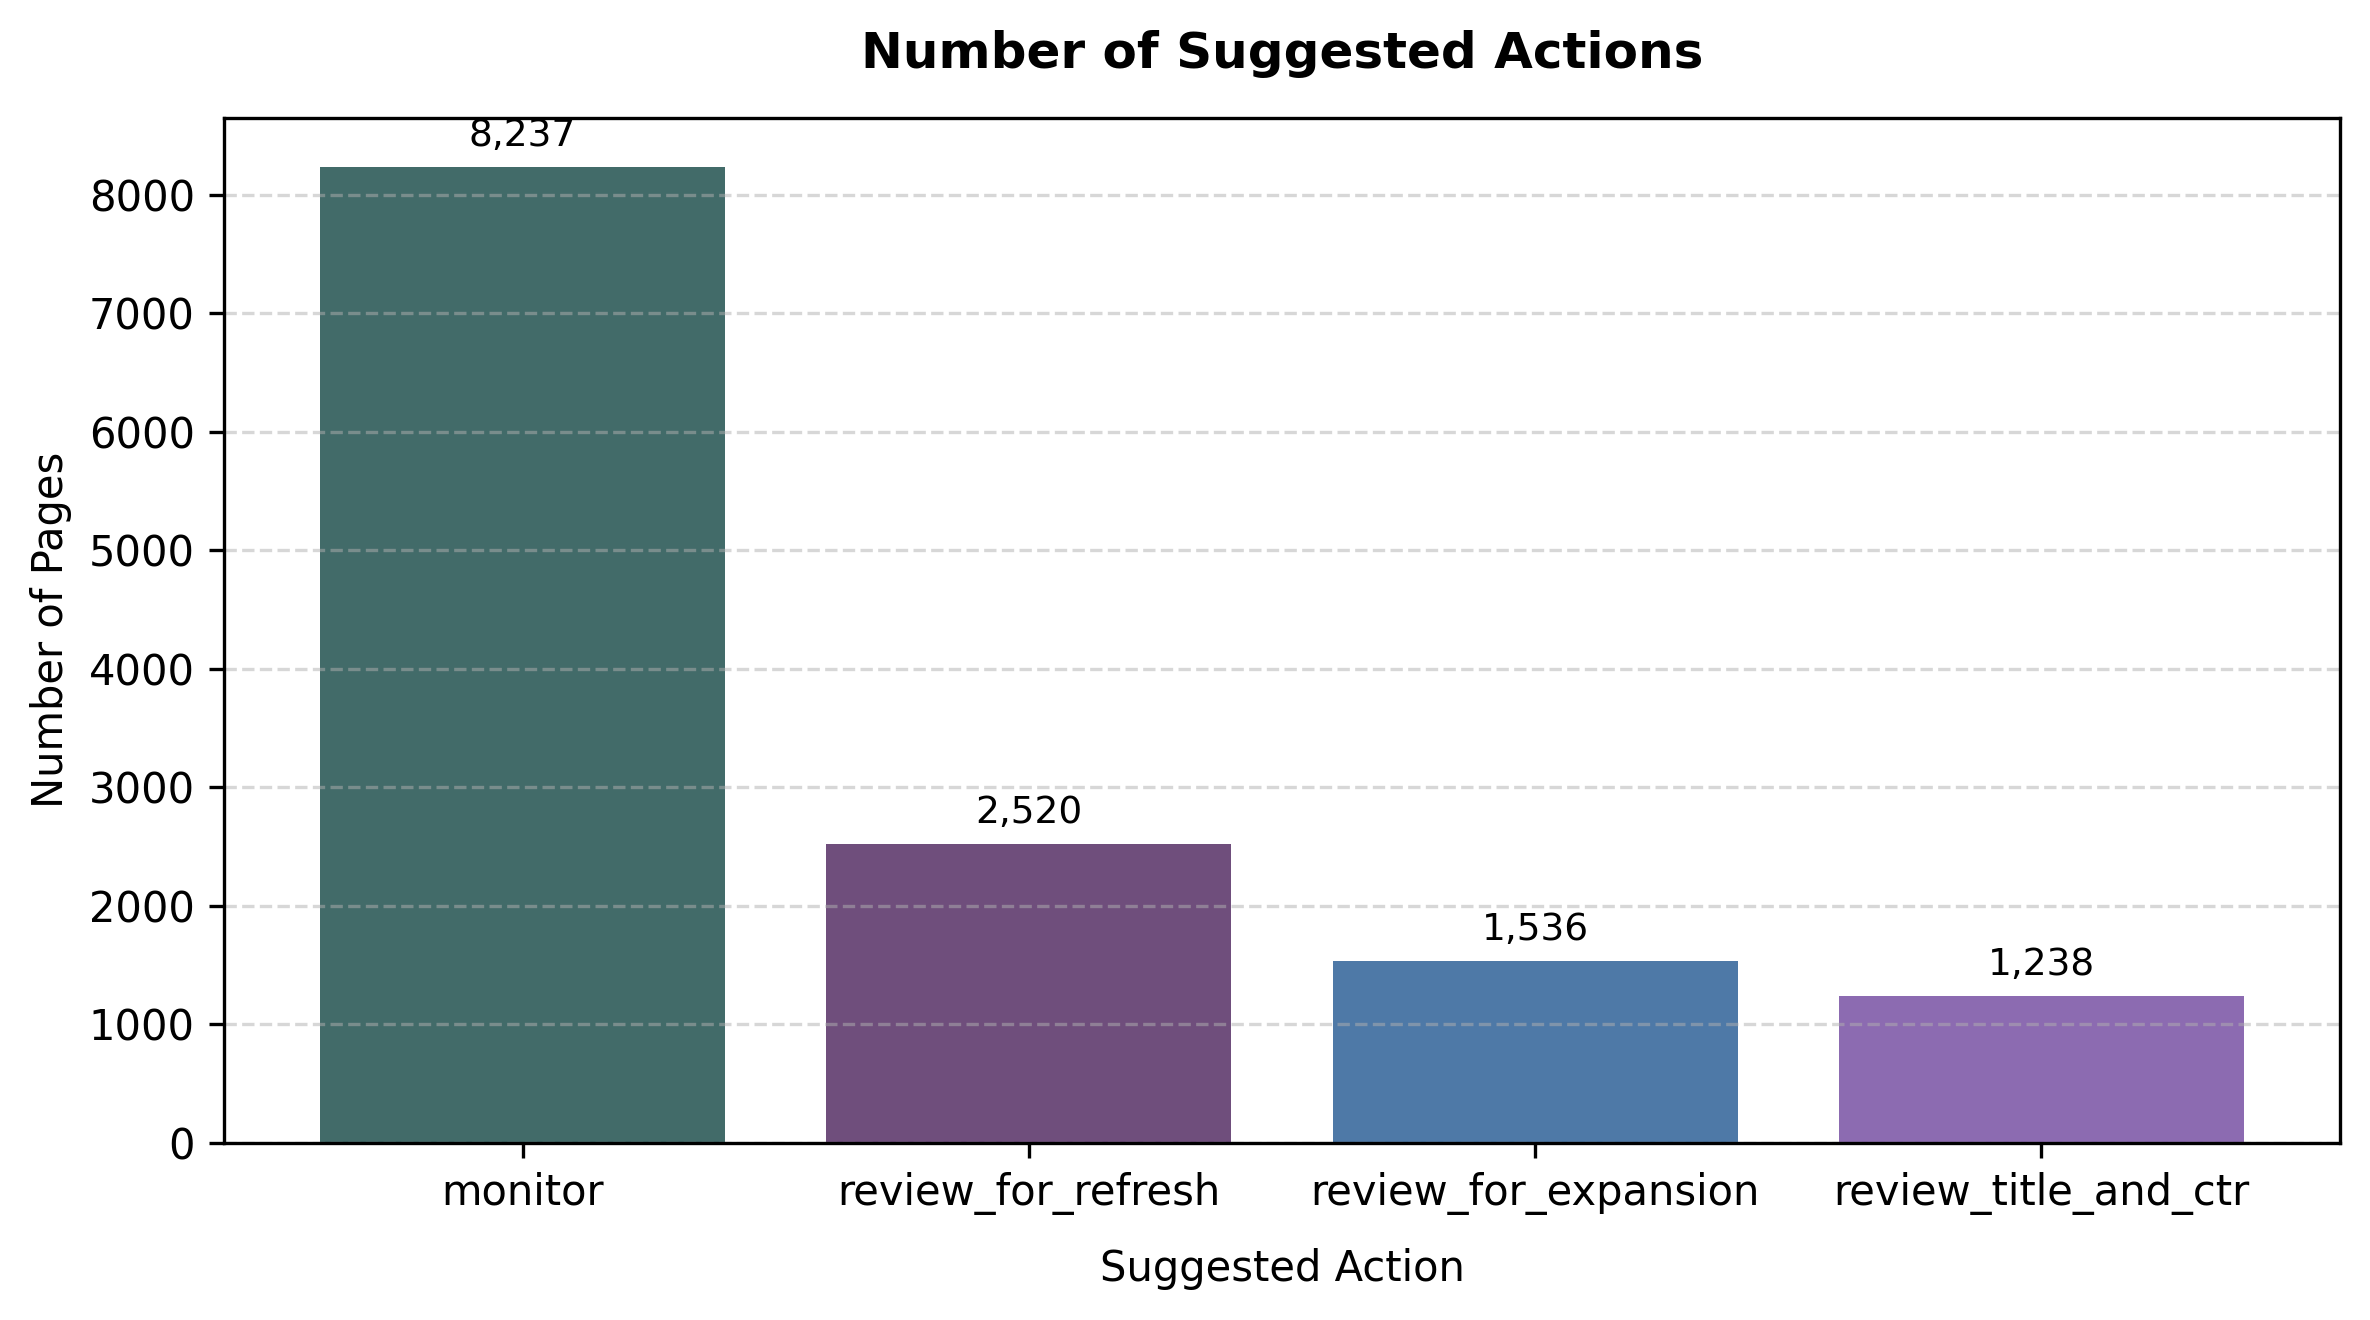

Saved figure to: work/figures/action_distribution.png


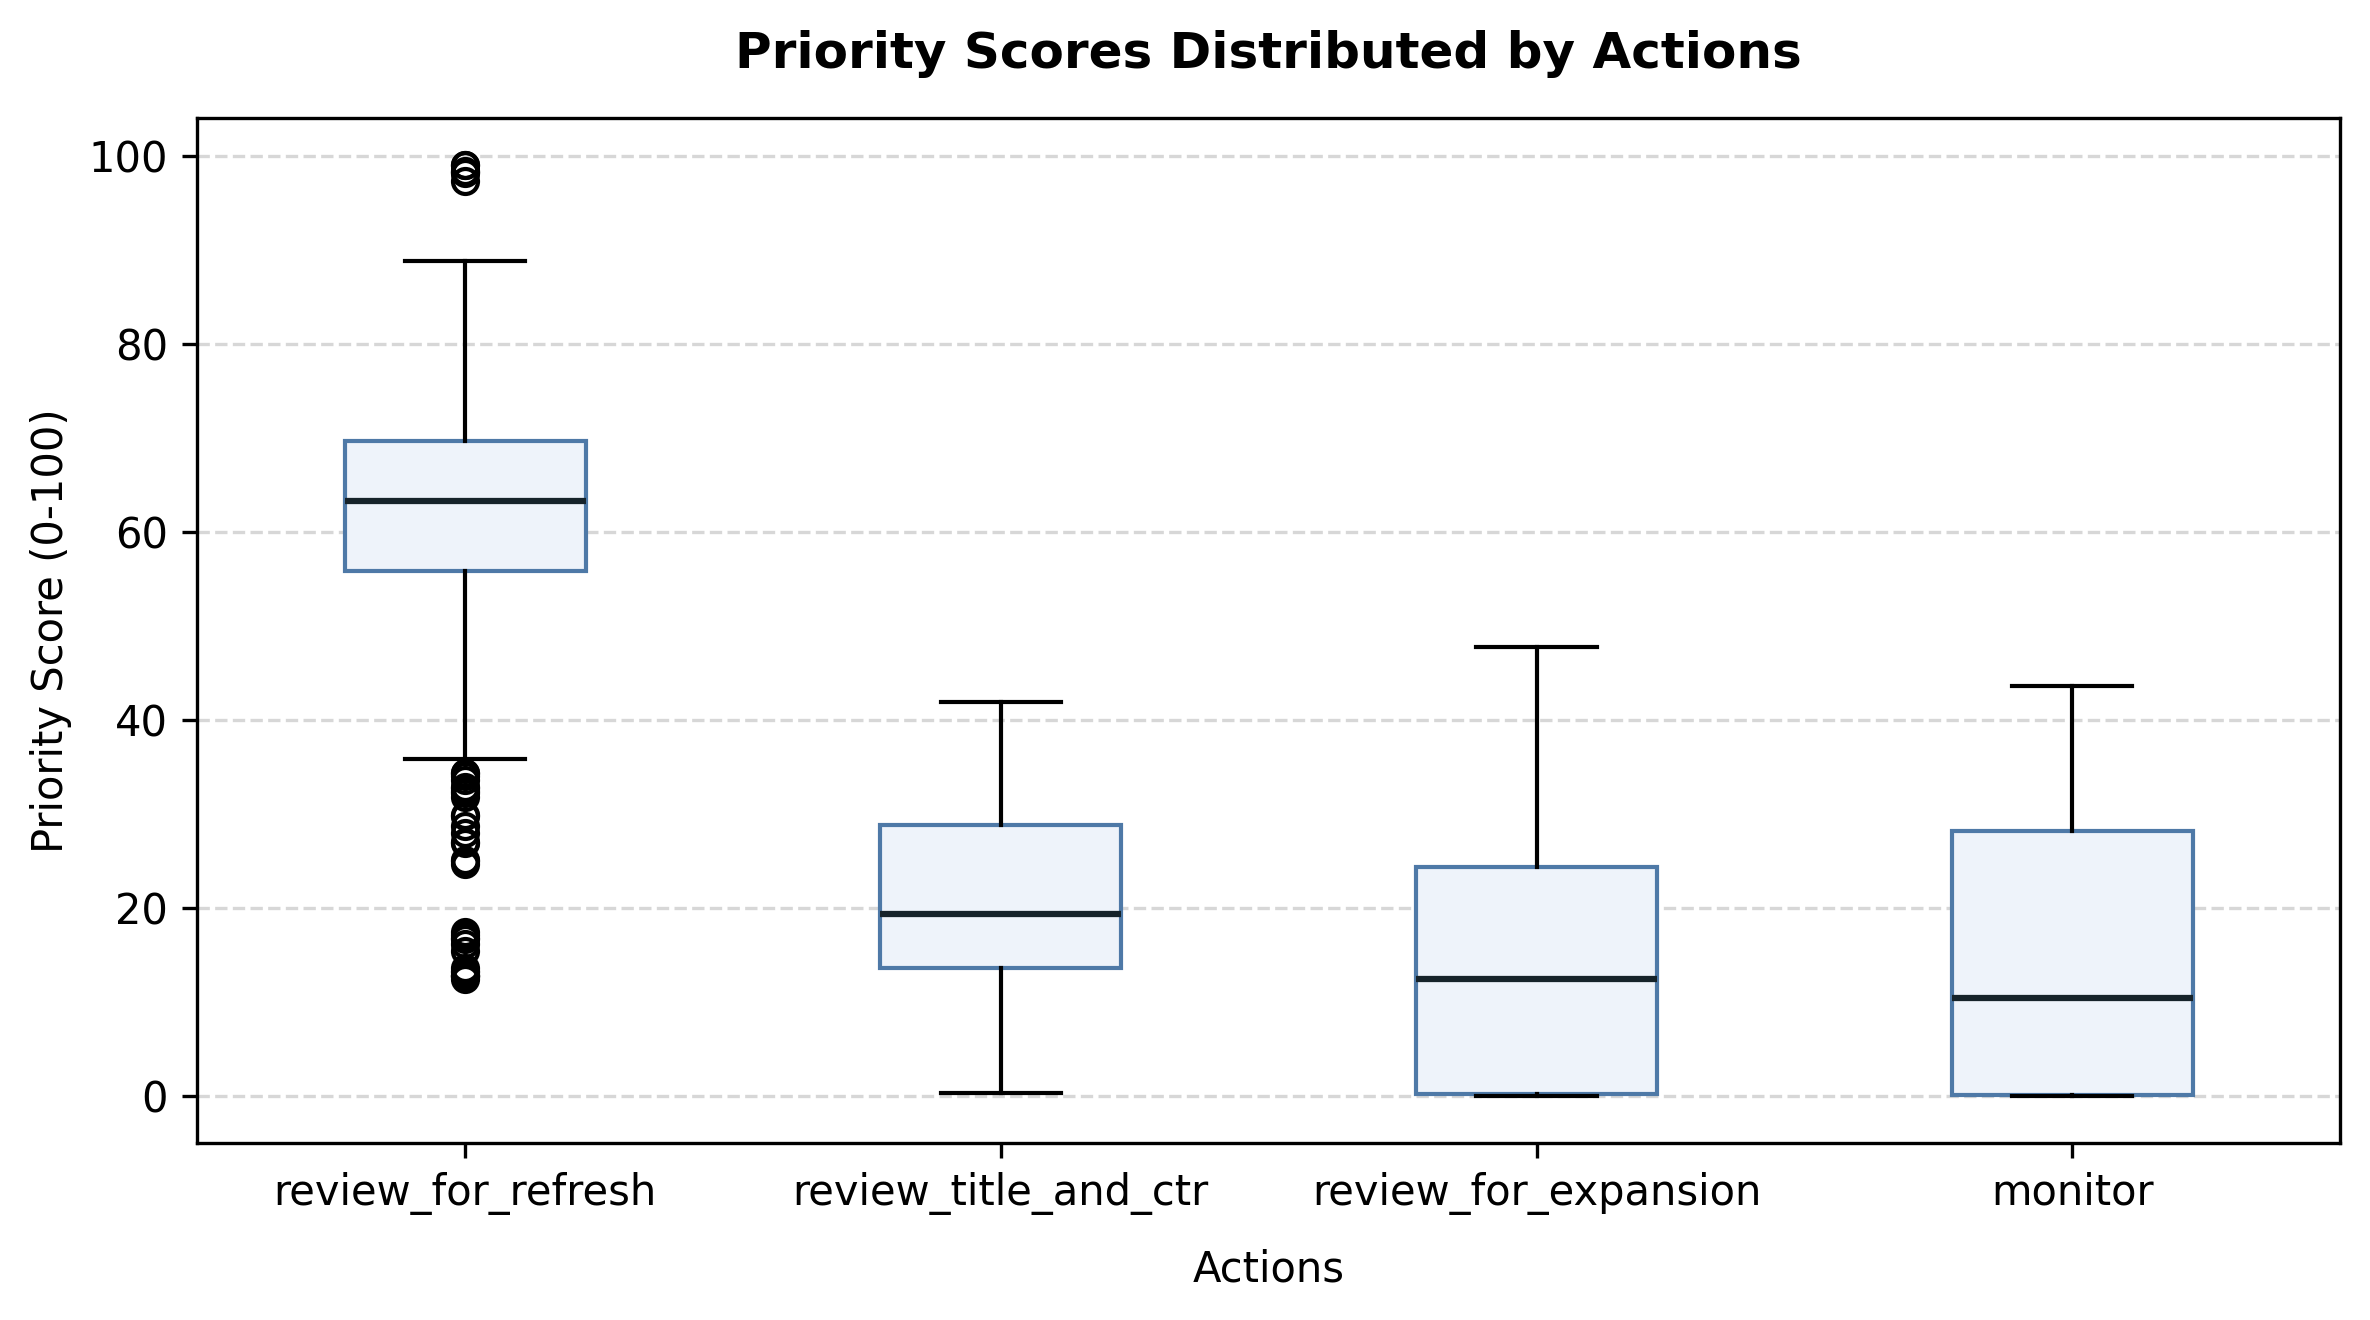

Saved figure to: work/figures/score_distribution.png

Saved metrics receipt to: work/outputs/refresh_queue_metrics.json
{
  "notebook": "capstone.ipynb",
  "timestamp": "2026-09-01 14:11:22",
  "total_pages_scored": 13531,
  "action_breakdown": {
    "monitor": 8237,
    "review_for_refresh": 2520,
    "review_for_expansion": 1536,
    "review_title_and_ctr": 1238
  },
  "visibility_breakdown": {
    "high": 6266,
    "medium": 6918,
    "low": 347
  },
  "priority_scores": {
    "highest_score": 99.1,
    "mean_score": 23.73,
    "80th_percentile_score": 40.5,
    "high_priority_review_count": 2713
  },
  "exported_artifacts": {
    "queue_csv": "work/outputs/refresh_queue.csv",
    "action_distribution_figure": "work/figures/action_distribution.png",
    "score_distribution_figure": "work/figures/score_distribution.png"
  }
}


In [11]:
import matplotlib.pyplot as plt
import json
import os

# Ensures output folders exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export ranked queue CSV
queue_export_columns = [
    "rank", "client_hash_id", "content_hash_id", "priority_score",
    "model_prob", "baseline_score", "suggested_action", "reasons",
    "week1_impressions", "w1_tier", "week2_impressions", "w2_tier"
]
queue[queue_export_columns].to_csv("work/outputs/refresh_queue.csv", index=False)
print("Saved ranked queue to: work/outputs/refresh_queue.csv")

# 1. Action Distribution Bar Chart
figure, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
action_counts = queue["suggested_action"].value_counts()
colors = ["#426B69", "#6F4E7C", "#4E79A7", "#8C6BB1"]

bars = ax.bar(action_counts.index, action_counts.values, color=colors[:len(action_counts)])
ax.set_title("Number of Suggested Actions", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Suggested Action", fontsize=10, labelpad=8)
ax.set_ylabel("Number of Pages", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
figure_action_path = "work/figures/action_distribution.png"
figure.savefig(figure_action_path)
plt.show()
plt.close(figure)
print(f"Saved figure to: {figure_action_path}")

# Priority score distribution by action
figure, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
action_order = ["review_for_refresh", "review_title_and_ctr", "review_for_expansion", "monitor"]
action_order = [a for a in action_order if a in queue["suggested_action"].unique()]

data_by_action = [queue[queue["suggested_action"] == a]["priority_score"].values for a in action_order]
ax.boxplot(data_by_action, tick_labels=action_order, patch_artist=True,
           boxprops=dict(facecolor="#EEF3FA", color="#4E79A7"),
           medianprops=dict(color="#16232A", linewidth=1.5))
ax.set_title("Priority Scores Distributed by Actions", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Actions", fontsize=10, labelpad=8)
ax.set_ylabel("Priority Score (0-100)", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
figure_score_path = "work/figures/score_distribution.png"
figure.savefig(figure_score_path)
plt.show()
plt.close(figure)
print(f"Saved figure to: {figure_score_path}")

# Export Summary JSON Receipt
visibility_counts = queue["visibility_bucket"].value_counts()
visibility_ordered = {
    tier: int(visibility_counts.get(tier, 0))
    for tier in ["high", "medium", "low"]
}

queue_metrics = {
    "notebook": "capstone.ipynb",
    "timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    "total_pages_scored": int(len(queue)),
    "action_breakdown": queue["suggested_action"].value_counts().to_dict(),
    "visibility_breakdown": visibility_ordered,
    "priority_scores": {
        "highest_score": float(queue["priority_score"].max()),
        "mean_score": float(queue["priority_score"].mean().round(2)),
        "80th_percentile_score": float(queue["priority_score"].quantile(0.80).round(2)),
        "high_priority_review_count": int((queue["priority_score"] >= queue["priority_score"].quantile(0.80)).sum())
    },
    "exported_artifacts": {
        "queue_csv": "work/outputs/refresh_queue.csv",
        "action_distribution_figure": figure_action_path,
        "score_distribution_figure": figure_score_path
    }
}

receipt_path = "work/outputs/refresh_queue_metrics.json"
with open(receipt_path, "w") as f:
    json.dump(queue_metrics, f, indent=2)

print(f"\nSaved metrics receipt to: {receipt_path}")
print(json.dumps(queue_metrics, indent=2))

## 8. Acknowledgements & data credit

This research was conducted as part of the Flyrank ML Internship, Refresh Opportunity Scoring lane

Built on the FlyRank ML Internship dataset https://flyrank.ai/

## Demo Outline

**Question:** Which pages should be reviewed first for expansion, reduction or refreshing based on changes in visibility and engagement compared to their previous rates?

**Method:** Create a ranked priority queue that ranks pages based on how likely they are to decline without being refreshed. The queue will also contain recommended actions to take based on patterns in the page's performance data

**Result:** My Random Forest model achieved the highest Precision@50 score of 0.876. This means that my Random Forest model was the most effective at correctly identifying declining pages. Therefore I selected my Random Forest as the final model to use. The chart below displays the number of times the Random Forest recommended each action

**Chart:** ![Action Distribution](https://raw.githubusercontent.com/JasperOwen/flyrank-ml-internship/main/work/figures/action_distribution.png)

**Recommendation:** Use the Random Forest's ranked output to assist the decision of which pages to review first, and what action to consider taking.

## Social Post
I explored whether machine learning could be used to help content editors decide which pages to review first, given limited time and resources.


Using 13,531 anonymised page records, I selected features and trained multiple models on them using client-held-out validation. My Random Forest Model achieved the highest Precision@50 score (0.876), making it the model I selected for the final prioritisation system.

My Random Forest model  ranks pages by their likelihood of meeting the study's defined decline conditions and recommends an editorial action based on patterns in the performance data of each page

**Chart:** ![Score Distribution](https://raw.githubusercontent.com/JasperOwen/flyrank-ml-internship/main/work/figures/score_distribution.png)

## Employer summary
**What I built:** A Random Forest model that produces a Ranked queue of web pages, ranked on how urgently they should be reviewed for refresh.

**The data I built it on** 13,531 anonymised page records from the FlyRank ML Internship dataset (https://flyrank.ai/), using performance metrics such as ranking position, impressions, clicks and CTR.

**What it showed:** The model can help identify pages that show patterns associated with future decline, while providing a suggested action such as refresh, expansion or title review.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
